### **Hierarchical Clustering:**

**Hierarchical clustering** is the third pillar alongside k-means and DBSCAN—different approach, complementary strengths:

**Agglomerative (bottom-up)** is most common:
- Start with N clusters (one per point), merge the closest pair each iteration
- Build a full dendrogram—a tree structure showing all merge operations and distances
- **Linkage method** controls how you measure cluster-to-cluster distance: single (minimum), complete (maximum), average (UPGMA), or Ward (variance minimization)
- **Advantage:** You get the full hierarchy—can cut at any height to get 2 to N clusters without rerunning
- **Disadvantage:** O(n²) space for distance matrix, O(n³) time naively (O(n² log n) with efficient algorithms like Lance-Williams)

**Divisive (top-down)** is less common but sometimes better for hierarchical structure:
- Start with all points in one cluster, recursively split using k-means (k=2) or other partition methods
- **Advantage:** Can capture top-level global structure before diving into details
- **Disadvantage:** More expensive and complex to implement

**Dendrogram interpretation:**
- Leaf nodes = individual points
- Internal nodes = merges; height of merge = distance between clusters
- Cut horizontally at a height to get a clustering—lower cuts = more clusters

**Linkage methods matter for shape:**
- **Single:** Chaining—elongated, connected clusters; chain reactions when close-neighbors pull distant points in
- **Complete:** Compact, isolated clusters; less chaining
- **Average:** Balanced; good default
- **Ward:** Minimizes within-cluster sum of squares; strong on globular data (similar bias to k-means)

**When to use hierarchical clustering:**
- You want to *explore* cluster structure across scales (dendrogram is a visual summary)
- You don't know how many clusters in advance (unlike k-means)
- Your clusters have nested/hierarchical structure naturally
- You need full reproducibility—no random seed sensitivity like k-means

### **Dendrogram Example:**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram, linkage

In [2]:
X = np.array([[0, 0], [1, 1], [5, 5], [6, 6]])

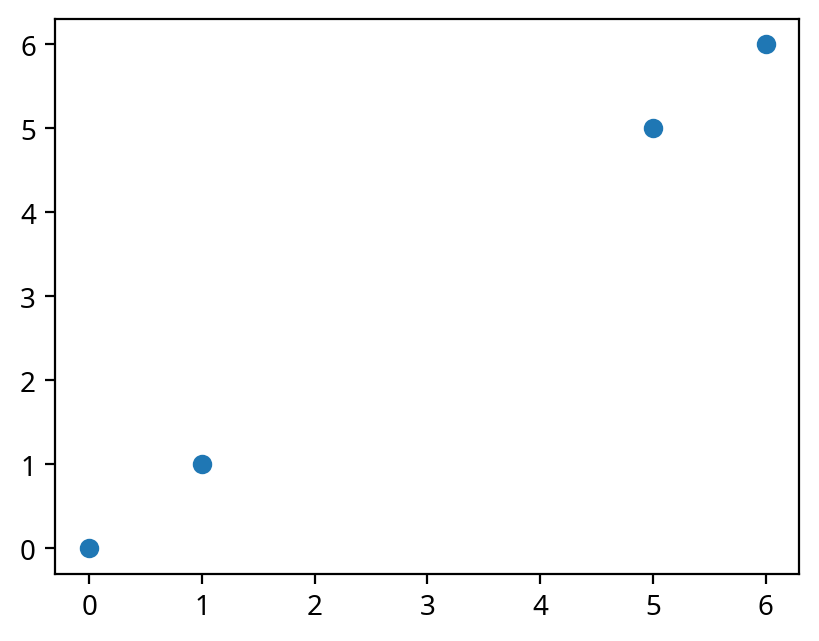

In [3]:
# Dot plot
plt.scatter(X[:, 0],X[:,1])
plt.show()

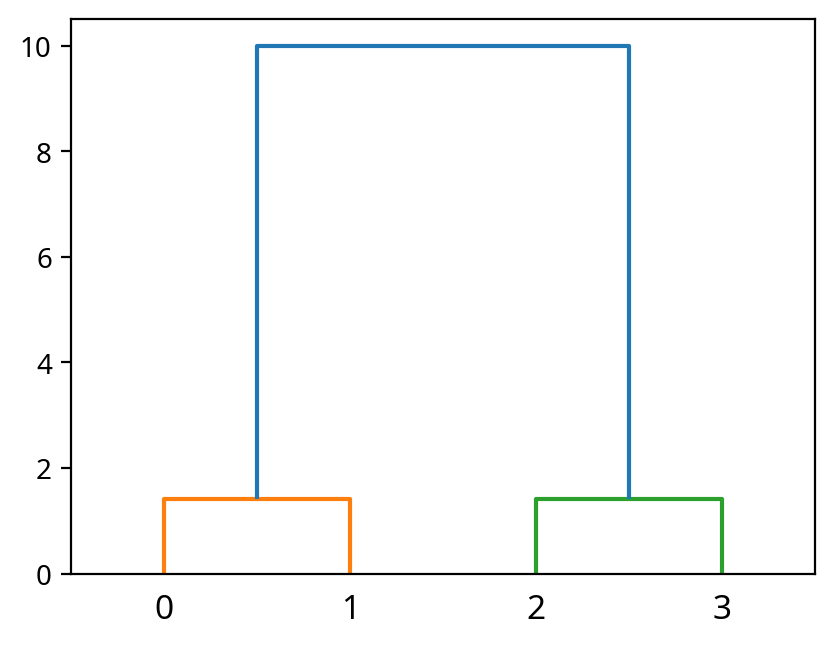

In [4]:
# Dendrogram
Z = linkage(X, method='ward')
dendrogram(Z);

### **Iris Data:**

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.datasets import load_iris
from sklearn.preprocessing import StandardScaler

#### Plot two features (Sepal Width, and Petal Width):

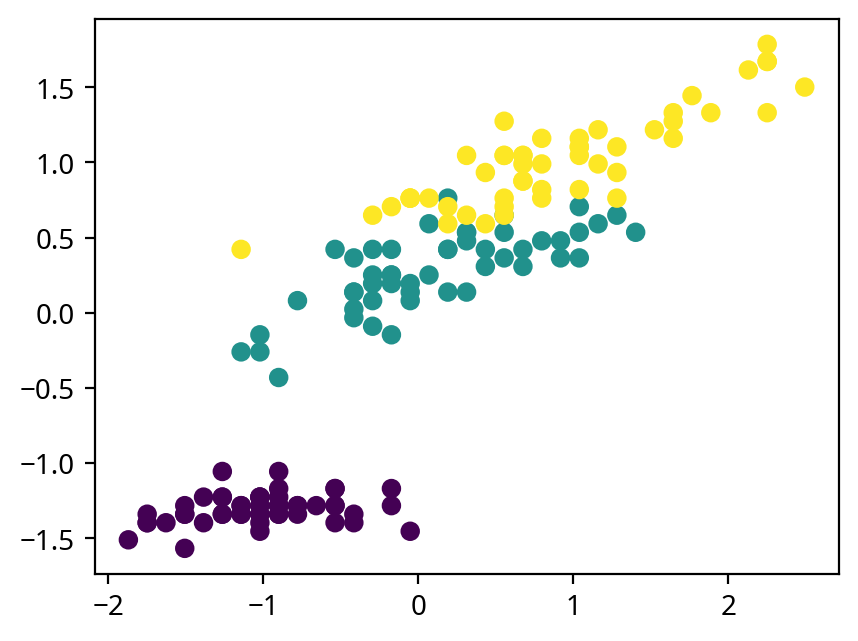

In [6]:
iris = load_iris()
X, y = iris['data'], iris['target']

X_stand = StandardScaler().fit_transform(X)[:, [0,2]]
plt.scatter(X_stand[:,0], X_stand[:, 1], c=y);

#### Review the dendrogram using scipy:

In [7]:
Z = linkage(X_stand, method='complete')

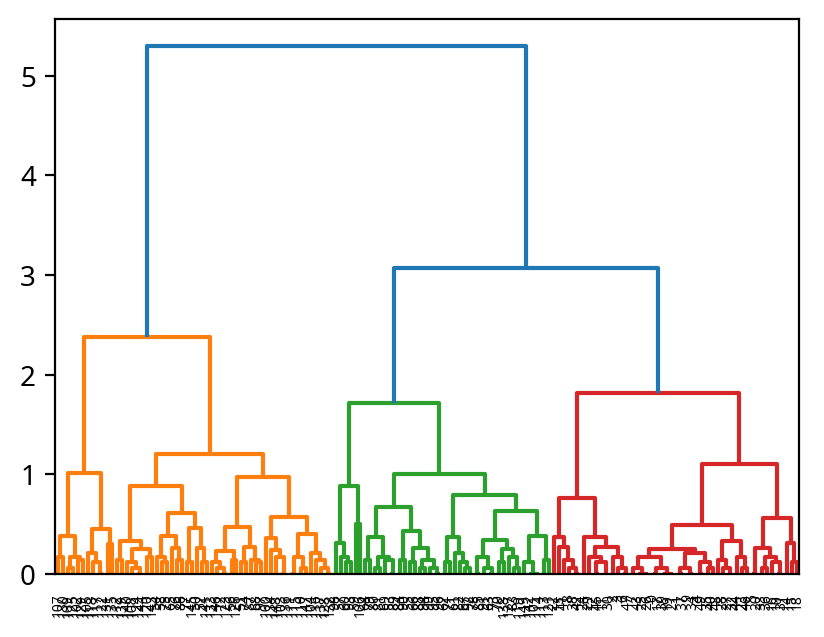

In [8]:
dendrogram(Z, color_threshold=3);

#### Sklearn

In [81]:
from itertools import permutations
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import accuracy_score, confusion_matrix

In [82]:
model = AgglomerativeClustering(n_clusters=3, linkage='complete')

In [75]:
y_pred = model.fit_predict(X_stand)

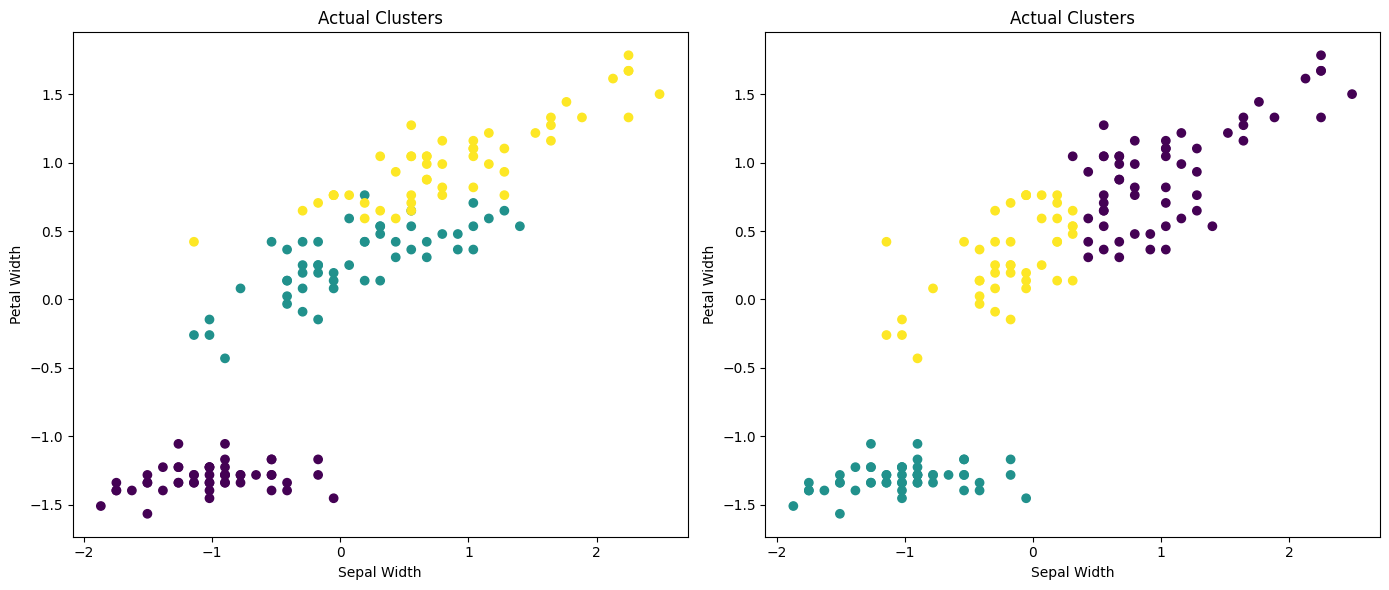

In [ ]:
fig, axes = plt.subplots(1,2, figsize=(14,6))

axes[0].scatter(X_stand[:,0], X_stand[:, 1], c=y)
axes[0].set_title('Actual Clusters')
axes[0].set_xlabel('Sepal Width')
axes[0].set_ylabel('Petal Width')

axes[1].scatter(X_stand[:,0], X_stand[:, 1], c=y_pred)
axes[1].set_title('Actual Clusters')
axes[1].set_xlabel('Sepal Width')
axes[1].set_ylabel('Petal Width')
plt.tight_layout()
plt.show()